### XGBoost Model

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

################### Load Data #####################################
df = pd.read_csv('2023ActualForecastData.csv')
df1 = pd.read_csv('2024ActualForecastData.csv')
df2 = pd.read_csv('2025ActualForecastData.csv')
AIL = pd.concat([df, df1, df2])
AIL = AIL.dropna(subset=['Hour', 'Date']).reset_index(drop=True) # Removes the extra hour from daylight savings time in November of each year

# Daylight saving time is ignored and the data set is left as is
AIL['Date'] = pd.to_datetime(AIL['Date']) + pd.to_timedelta(AIL['Hour'], unit='h')
print(AIL.head())
print(AIL.tail())


                 Date  Hour  Forecast Pool Price  Actual Posted Pool Price  \
0 2023-01-01 01:00:00   1.0                88.39                     80.55   
1 2023-01-01 02:00:00   2.0               102.36                     80.84   
2 2023-01-01 03:00:00   3.0                80.82                     80.63   
3 2023-01-01 04:00:00   4.0                80.61                     79.76   
4 2023-01-01 05:00:00   5.0                77.88                     79.53   

   Forecast AIL  Actual AIL  Forecast AIL & Actual AIL Difference  
0          9832        9824                                     8  
1          9723        9712                                    11  
2          9634        9623                                    11  
3          9578        9578                                     0  
4          9541        9599                                   -58  
                     Date  Hour  Forecast Pool Price  \
26296 2025-12-31 20:00:00  20.0                19.92   
26297 2025-

### Create Model Features

In [3]:
def create_features(data):
    """
    :param data: Series with DatetimeIndex
    :return: DataFrame
    """
    data = data.copy()  # ← avoid modifying original DataFrame

    # Time features
    data['Hour'] = data['Date'].dt.hour
    data['Day'] = data['Date'].dt.dayofweek
    data['Month'] = data['Date'].dt.month
    data['is_weekend'] = (data['Date'].dt.dayofweek >= 5).astype(int)

    # Lagged features, how much the previous day affects the current day ie. Autoregression
    data['lag1'] = data['Actual AIL'].shift(1) # 1 hour ago
    data['lag24'] = data['Actual AIL'].shift(24) # 24 hours ago
    data['lag168'] = data['Actual AIL'].shift(168) # Same day last week

    # Moving Average
    # Shift 1 as to not include current value
    data['MA3'] = data['Actual AIL'].shift(1).rolling(3).mean() # 3-hour average
    data['MA24'] = data['Actual AIL'].shift(1).rolling(24).mean() # 24-hour average
    data['MA168'] = data['Actual AIL'].shift(1).rolling(168).mean() # Weekly average

    data = data.dropna()

    feature_cols = ['Hour', 'Day', 'Month', 'is_weekend',
                'lag1', 'lag24', 'lag168', 'MA3', 'MA24', 'MA168']
    X = data[feature_cols]  # Features used to predict
    Y = data['Actual AIL']  # Target what is getting predicted

    return X, Y

### Walk Forward Validation

Walk-forward validation iteratively trains and tests a model on a consistent window size across consecutive periods. Think of it like a sliding window — at each step the model is retrained on the most recent historical window and tested on the next unseen period, ensuring the model only learns from the past. This allows the model to capture evolving patterns and detect structural drifts in the data over time.

#### Walk Forward Validation: Deriving Window Size
##### Problem

Given a dataset of length `len(DF)`, a desired number of folds `n_folds`, and a training spilt ratio `r`, find:
- `x` — the step size
- `y` — the fold length (training window + test window)

---

#### Two Equations, Two Unknowns

##### Equation 1 — Rolling Window Formula

Each fold advances by one step `x`, and the first fold requires a full fold length `y`:

$$\text{len(DF)} = y + ( \text{nfolds} - 1) \cdot x$$

##### Equation 2 — Train/Test Ratio

Given a training ratio `r`, the fold length `y` is related to the step `x` by:

$$y = \frac{x}{1 - r}$$

---

In [4]:
def walk_forward_validation_performance(DataFrame, n_folds, train_window_ratio, feature_function):
    """
    This function applies a walk forward validation to assess model performance.
    :param: Dataframe, with time
    :param: n_folds, number of folds
    :param: train_window_ratio,
    :param: feature_function,
    :return: Mean_squared_error, RMSE,  Actual_AIL, Predicted_AIL
    """
    actual_AIL = []
    predicted_AIL = []

    total = len(DataFrame)
    fold_length = int(total/(1 + (n_folds - 1)*(1-train_window_ratio)))
    step_size = int(fold_length*(1 - train_window_ratio))
    training_window = fold_length - step_size

    # range(start, stop, step)
    for i in range(
        0, total - fold_length, step_size
    ):
        # Split data into training and testing sets
        train_dataset = DataFrame[i:i + training_window]
        test_dataset = DataFrame[i + training_window: i + training_window + step_size]

        # Prepare features for training and testing
        X_train, Y_train = feature_function(train_dataset)
        X_test, Y_test = feature_function(test_dataset)

        model = xgb.XGBRegressor(
            n_estimators=500,   # Number of trees to build
            learning_rate=0.05, # How much each tree contributes
            max_depth=3,        # How many levels of questions
            random_state=42
        )

        model.fit(X_train, Y_train)
        preds = model.predict(X_test)

        actual_AIL.extend(Y_test)
        predicted_AIL.extend(preds)

    mse = mean_squared_error(actual_AIL, predicted_AIL)
    rmse = mse ** 0.5

    return {
        'mse'           : mse,
        'rmse'          : rmse,
        'actual_AIL'    : actual_AIL,
        'predicted_AIL' : predicted_AIL
    }

### Plot Results and Residual Analysis

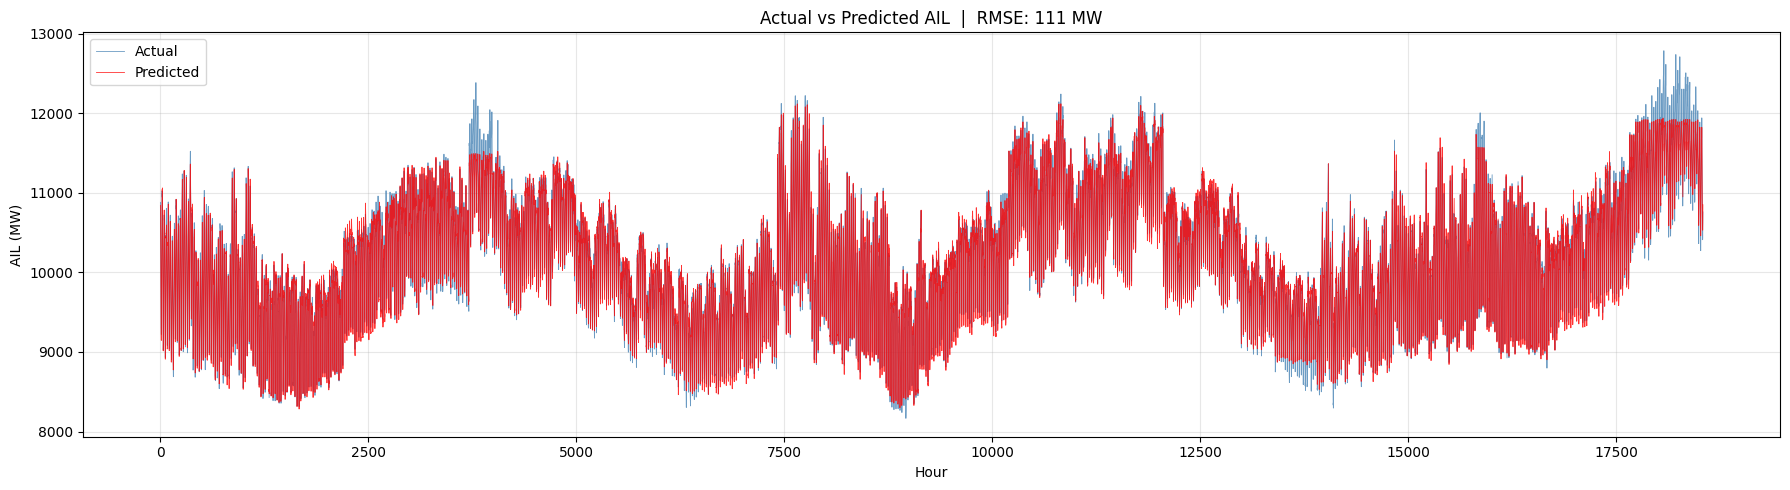

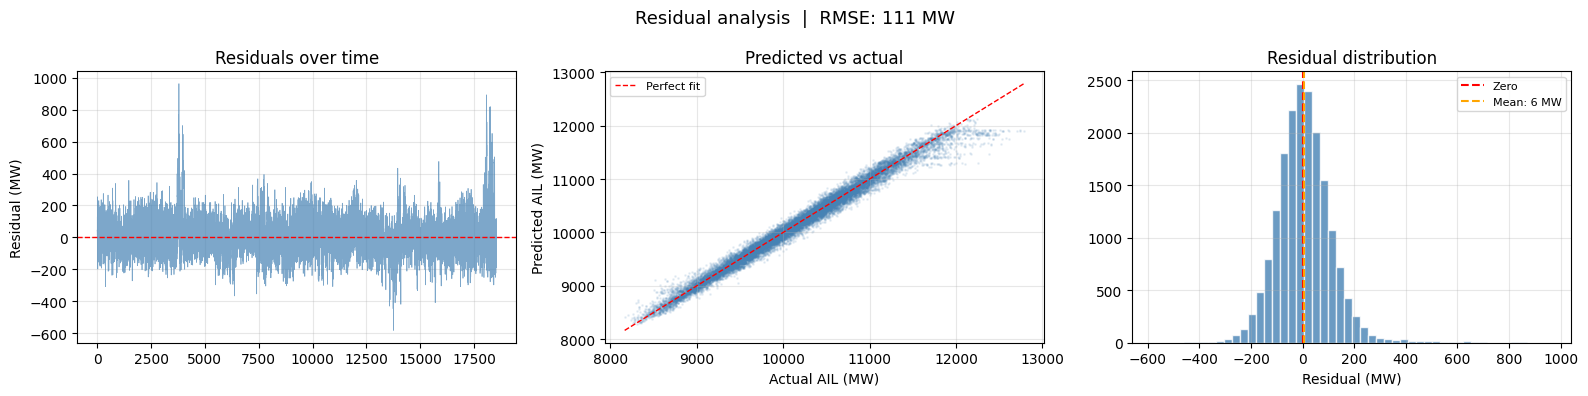

In [11]:
# Run the Walk Forward Validation Process
results = walk_forward_validation_performance(
    AIL,
    n_folds=20,
    train_window_ratio=0.8,
    feature_function=create_features
)

Actual_AIL = np.array(results['actual_AIL'])
Predicted_AIL = np.array(results['predicted_AIL'])
Residuals = Actual_AIL - Predicted_AIL

# Plot results
plt.figure(figsize=(18, 5))
plt.plot(Actual_AIL,    lw=0.6, alpha=0.8, color='steelblue', label='Actual')
plt.plot(Predicted_AIL, lw=0.6, alpha=0.8, color='red',       label='Predicted')
plt.title(f'Actual vs Predicted AIL  |  RMSE: {results["rmse"]:,.0f} MW')
plt.xlabel('Hour')
plt.ylabel('AIL (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Residual Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Residuals over time — look for patterns/drift
axes[0].plot(Residuals, lw=0.5, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', ls='--', lw=1)
axes[0].set_title('Residuals over time')
axes[0].set_ylabel('Residual (MW)')
axes[0].grid(True, alpha=0.3)

# 2. Predicted vs Actual — perfect model = straight diagonal line
axes[1].scatter(Actual_AIL, Predicted_AIL, alpha=0.1, s=1, color='steelblue')
axes[1].plot([Actual_AIL.min(), Actual_AIL.max()], [Actual_AIL.min(), Actual_AIL.max()], 'r--', lw=1, label='Perfect fit')
axes[1].set_xlabel('Actual AIL (MW)')
axes[1].set_ylabel('Predicted AIL (MW)')
axes[1].set_title('Predicted vs actual')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3. Residual distribution — should be centered at 0
axes[2].hist(Residuals, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(0, color='red', ls='--', label='Zero')
axes[2].axvline(Residuals.mean(), color='orange', ls='--', label=f'Mean: {Residuals.mean():.0f} MW')
axes[2].set_xlabel('Residual (MW)')
axes[2].set_title('Residual distribution')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Residual analysis  |  RMSE: {results["rmse"]:,.0f} MW', fontsize=13)
plt.tight_layout()
plt.show()


In [6]:
AIL['Actual AIL'].describe()
print(f"% above 11,700: {(AIL['Actual AIL'] > 11700).mean() * 100:.1f}%")
print(f"% above 12,000: {(AIL['Actual AIL'] > 12000).mean() * 100:.1f}%")

print(f"Training window size : {int(5256 * 0.8)} hours")
print(f"Lag168 requires      : 168 hours of history")
print(f"Safe to proceed      : {int(5256 * 0.8) > 168}")  # Should be True

% above 11,700: 2.9%
% above 12,000: 0.9%
Training window size : 4204 hours
Lag168 requires      : 168 hours of history
Safe to proceed      : True
